In [1]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('D:\project\dataset\CSV_Files\Train_UWu5bXk.csv')
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


array([[<AxesSubplot:title={'center':'Item_Weight'}>,
        <AxesSubplot:title={'center':'Item_Visibility'}>],
       [<AxesSubplot:title={'center':'Item_MRP'}>,
        <AxesSubplot:title={'center':'Outlet_Establishment_Year'}>],
       [<AxesSubplot:title={'center':'Item_Outlet_Sales'}>,
        <AxesSubplot:>]], dtype=object)

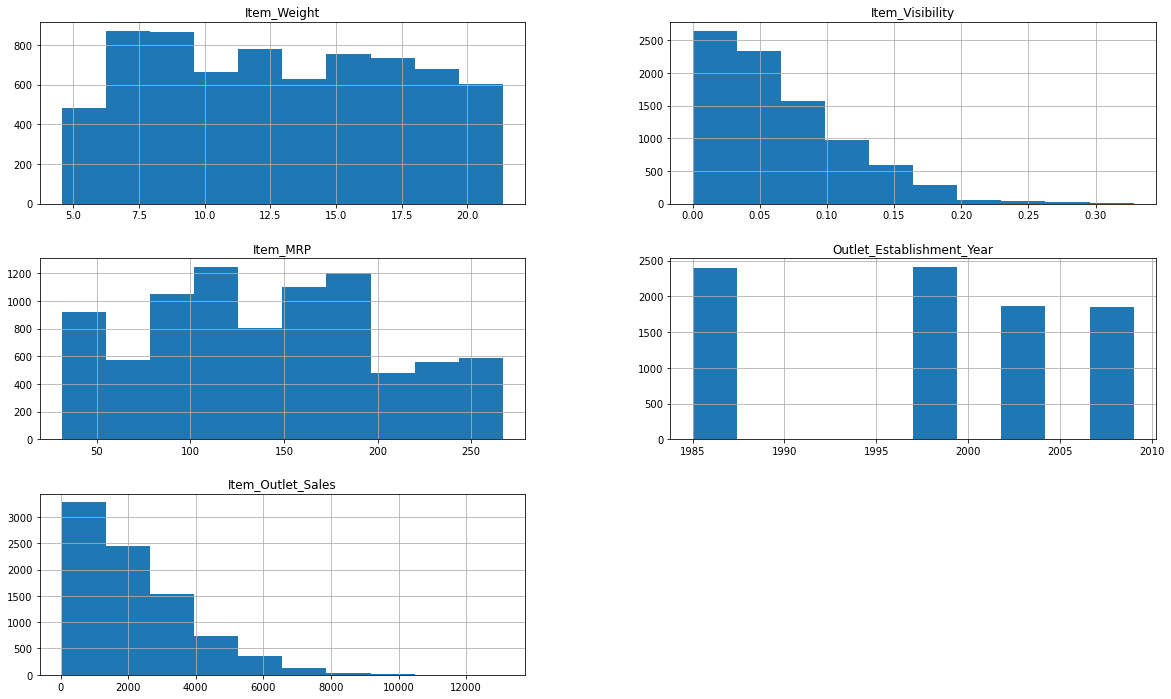

In [4]:
data.hist(figsize=(20, 12))

In [5]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
X = data[['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']]
y = data['Item_Outlet_Sales']

In [7]:
X.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store
4,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1


In [8]:
X_Scaled = X.copy()
cont_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']
scaler = StandardScaler()
X_Scaled = X_Scaled[cont_cols]
X_Scaled = scaler.fit_transform(X_Scaled)
print(X_Scaled)

[[-0.7662174  -0.97073217  1.74745381  0.13954076]
 [-1.49417499 -0.90811123 -1.48902325  1.33410274]
 [ 0.99983356 -0.95691733  0.01004021  0.13954076]
 ...
 [-0.48623371 -0.59978449 -0.89720755  0.73682175]
 [-1.21634502  1.53287976 -0.60797692  1.33410274]
 [ 0.41832897 -0.41193591 -1.05226104 -0.09937163]]


In [9]:
X[cont_cols] = X_Scaled

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


In [10]:
X.head(10)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,-0.766217,Low Fat,-0.970732,Dairy,1.747454,OUT049,0.139541,Medium,Tier 1,Supermarket Type1
1,-1.494175,Regular,-0.908111,Soft Drinks,-1.489023,OUT018,1.334103,Medium,Tier 3,Supermarket Type2
2,0.999834,Low Fat,-0.956917,Meat,0.010040,OUT049,0.139541,Medium,Tier 1,Supermarket Type1
3,1.365966,Regular,-1.281758,Fruits and Vegetables,0.660050,OUT010,0.020085,NaN,Tier 3,Grocery Store
4,-0.845905,Low Fat,-1.281758,Household,-1.399220,OUT013,-1.293934,High,Tier 3,Supermarket Type1
5,-0.530385,Regular,-1.281758,Baking Goods,-1.438734,OUT018,1.334103,Medium,Tier 3,Supermarket Type2
6,0.170651,Regular,-1.034813,Snack Foods,-1.338238,OUT013,-1.293934,High,Tier 3,Supermarket Type1
7,NaN,Low Fat,1.188838,Snack Foods,-0.533641,OUT027,-1.532846,Medium,Tier 3,Supermarket Type3
8,0.719850,Regular,-0.958331,Frozen Foods,-0.706908,OUT045,0.497909,NaN,Tier 2,Supermarket Type1
9,1.365966,Regular,0.548845,Frozen Foods,0.752008,OUT017,1.095190,NaN,Tier 2,Supermarket Type1


In [11]:
cat_cols_indexes = [1, 3, 5, 7, 8, 9]

In [12]:
X['Outlet_Size'].isna()

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool

In [13]:
X['Outlet_Size'].fillna(X['Outlet_Size'].mode()[0], inplace=True)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [14]:
X.isnull().sum()


Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2323)

In [16]:
model = CatBoostRegressor(iterations=2000, learning_rate=0.05, depth=8, eval_metric='MAE')

In [17]:
model.fit(X_train, y_train, cat_cols_indexes, eval_set=(X_test, y_test), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1316.0864765	test: 1278.7152391	best: 1278.7152391 (0)	total: 118ms	remaining: 3m 56s
1:	learn: 1279.3288313	test: 1242.6160864	best: 1242.6160864 (1)	total: 212ms	remaining: 3m 32s
2:	learn: 1246.3163160	test: 1210.2324168	best: 1210.2324168 (2)	total: 310ms	remaining: 3m 26s
3:	learn: 1213.6203214	test: 1177.9197181	best: 1177.9197181 (3)	total: 402ms	remaining: 3m 20s
4:	learn: 1183.2134877	test: 1148.2406256	best: 1148.2406256 (4)	total: 463ms	remaining: 3m 4s
5:	learn: 1155.0455531	test: 1121.4909495	best: 1121.4909495 (5)	total: 548ms	remaining: 3m 2s
6:	learn: 1128.0204397	test: 1096.1503373	best: 1096.1503373 (6)	total: 612ms	remaining: 2m 54s
7:	learn: 1103.8170195	test: 1073.4848067	best: 1073.4848067 (7)	total: 682ms	remaining: 2m 49s
8:	learn: 1081.8358461	test: 1052.1395898	best: 1052.1395898 (8)	total: 745ms	remaining: 2m 44s
9:	learn: 1059.4212664	test: 1030.7187503	best: 1030.7187503 (9)	total: 844ms	remaining: 2m 48s
10:	learn: 1041.3437966	test: 1013.5461506

89:	learn: 743.2080927	test: 744.0284142	best: 744.0284142 (89)	total: 7.56s	remaining: 2m 40s
90:	learn: 743.0168786	test: 743.9896599	best: 743.9896599 (90)	total: 7.65s	remaining: 2m 40s
91:	learn: 742.6856837	test: 744.0012639	best: 743.9896599 (90)	total: 7.75s	remaining: 2m 40s
92:	learn: 742.0351451	test: 744.0054948	best: 743.9896599 (90)	total: 7.84s	remaining: 2m 40s
93:	learn: 741.6850713	test: 743.9289591	best: 743.9289591 (93)	total: 7.93s	remaining: 2m 40s
94:	learn: 740.9801873	test: 743.9979690	best: 743.9289591 (93)	total: 8.02s	remaining: 2m 40s
95:	learn: 740.7934823	test: 743.9510382	best: 743.9289591 (93)	total: 8.11s	remaining: 2m 40s
96:	learn: 740.5647457	test: 743.7889414	best: 743.7889414 (96)	total: 8.2s	remaining: 2m 40s
97:	learn: 740.3716626	test: 743.6888379	best: 743.6888379 (97)	total: 8.31s	remaining: 2m 41s
98:	learn: 740.0901589	test: 743.5721886	best: 743.5721886 (98)	total: 8.39s	remaining: 2m 41s
99:	learn: 739.8774370	test: 743.5273155	best: 743.

175:	learn: 722.4181562	test: 742.1417417	best: 742.1417417 (175)	total: 15s	remaining: 2m 35s
176:	learn: 722.3027151	test: 742.1851420	best: 742.1417417 (175)	total: 15.1s	remaining: 2m 35s
177:	learn: 721.8351326	test: 742.1427653	best: 742.1417417 (175)	total: 15.2s	remaining: 2m 36s
178:	learn: 721.2054741	test: 741.8456024	best: 741.8456024 (178)	total: 15.4s	remaining: 2m 36s
179:	learn: 720.7648471	test: 741.7447898	best: 741.7447898 (179)	total: 15.5s	remaining: 2m 36s
180:	learn: 720.5251849	test: 741.8219256	best: 741.7447898 (179)	total: 15.5s	remaining: 2m 36s
181:	learn: 720.1297169	test: 741.9009304	best: 741.7447898 (179)	total: 15.7s	remaining: 2m 36s
182:	learn: 719.6621972	test: 741.9861878	best: 741.7447898 (179)	total: 15.8s	remaining: 2m 36s
183:	learn: 719.2215050	test: 741.9069589	best: 741.7447898 (179)	total: 15.9s	remaining: 2m 36s
184:	learn: 719.1203483	test: 741.9103743	best: 741.7447898 (179)	total: 16s	remaining: 2m 36s
185:	learn: 718.8920424	test: 741.

263:	learn: 696.8258128	test: 741.9102519	best: 741.4144464 (196)	total: 23.6s	remaining: 2m 35s
264:	learn: 696.7397931	test: 741.9444197	best: 741.4144464 (196)	total: 23.6s	remaining: 2m 34s
265:	learn: 696.3612790	test: 741.9738423	best: 741.4144464 (196)	total: 23.7s	remaining: 2m 34s
266:	learn: 696.0319717	test: 742.2115539	best: 741.4144464 (196)	total: 23.8s	remaining: 2m 34s
267:	learn: 695.6666594	test: 742.2897743	best: 741.4144464 (196)	total: 23.8s	remaining: 2m 34s
268:	learn: 695.2998847	test: 742.2972212	best: 741.4144464 (196)	total: 23.9s	remaining: 2m 33s
269:	learn: 695.0403461	test: 742.4348593	best: 741.4144464 (196)	total: 24s	remaining: 2m 33s
270:	learn: 694.7431223	test: 742.4835394	best: 741.4144464 (196)	total: 24s	remaining: 2m 33s
271:	learn: 694.3978126	test: 742.4572906	best: 741.4144464 (196)	total: 24.1s	remaining: 2m 33s
272:	learn: 694.0615928	test: 742.4807422	best: 741.4144464 (196)	total: 24.2s	remaining: 2m 32s
273:	learn: 693.6104955	test: 742.

...

1653:	learn: 447.3084897	test: 761.5862882	best: 741.4144464 (196)	total: 2m 39s	remaining: 33.3s
1654:	learn: 447.2274862	test: 761.6057097	best: 741.4144464 (196)	total: 2m 39s	remaining: 33.2s
1655:	learn: 447.1439769	test: 761.7029254	best: 741.4144464 (196)	total: 2m 39s	remaining: 33.1s
1656:	learn: 446.9832188	test: 761.7367398	best: 741.4144464 (196)	total: 2m 39s	remaining: 33s
1657:	learn: 446.9509909	test: 761.7472162	best: 741.4144464 (196)	total: 2m 39s	remaining: 32.9s
1658:	learn: 446.7009250	test: 761.7105749	best: 741.4144464 (196)	total: 2m 39s	remaining: 32.8s
1659:	learn: 446.5777110	test: 761.7534088	best: 741.4144464 (196)	total: 2m 39s	remaining: 32.7s
1660:	learn: 446.5161175	test: 761.8328248	best: 741.4144464 (196)	total: 2m 39s	remaining: 32.6s
1661:	learn: 446.4582355	test: 761.8312259	best: 741.4144464 (196)	total: 2m 39s	remaining: 32.5s
1662:	learn: 446.3856484	test: 761.8900606	best: 741.4144464 (196)	total: 2m 40s	remaining: 32.4s
1663:	learn: 446.36431

1737:	learn: 437.5711944	test: 762.6044198	best: 741.4144464 (196)	total: 2m 46s	remaining: 25.1s
1738:	learn: 437.4372509	test: 762.6533948	best: 741.4144464 (196)	total: 2m 46s	remaining: 25.1s
1739:	learn: 437.3727687	test: 762.6853225	best: 741.4144464 (196)	total: 2m 47s	remaining: 25s
1740:	learn: 437.2924730	test: 762.6736055	best: 741.4144464 (196)	total: 2m 47s	remaining: 24.9s
1741:	learn: 437.1828186	test: 762.6748084	best: 741.4144464 (196)	total: 2m 47s	remaining: 24.8s
1742:	learn: 437.0206650	test: 762.7182723	best: 741.4144464 (196)	total: 2m 47s	remaining: 24.7s
1743:	learn: 436.9302618	test: 762.7002478	best: 741.4144464 (196)	total: 2m 47s	remaining: 24.6s
1744:	learn: 436.7623146	test: 762.6818104	best: 741.4144464 (196)	total: 2m 47s	remaining: 24.5s
1745:	learn: 436.5137520	test: 762.7986860	best: 741.4144464 (196)	total: 2m 47s	remaining: 24.4s
1746:	learn: 436.4118592	test: 762.7963640	best: 741.4144464 (196)	total: 2m 47s	remaining: 24.3s
1747:	learn: 436.29832

1823:	learn: 427.8993182	test: 763.3729920	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.9s
1824:	learn: 427.7153452	test: 763.4469054	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.8s
1825:	learn: 427.6749071	test: 763.4701183	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.7s
1826:	learn: 427.5703203	test: 763.4860693	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.6s
1827:	learn: 427.4754050	test: 763.5237400	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.5s
1828:	learn: 427.4512286	test: 763.5274372	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.4s
1829:	learn: 427.1812894	test: 763.5191198	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.3s
1830:	learn: 427.1161889	test: 763.4948810	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.2s
1831:	learn: 427.0337637	test: 763.5376199	best: 741.4144464 (196)	total: 2m 55s	remaining: 16.1s
1832:	learn: 426.9461911	test: 763.5216432	best: 741.4144464 (196)	total: 2m 55s	remaining: 16s
1833:	learn: 426.82428

1909:	learn: 419.1892644	test: 764.3723281	best: 741.4144464 (196)	total: 3m 3s	remaining: 8.63s
1910:	learn: 419.1040976	test: 764.4189352	best: 741.4144464 (196)	total: 3m 3s	remaining: 8.53s
1911:	learn: 419.0298239	test: 764.4590246	best: 741.4144464 (196)	total: 3m 3s	remaining: 8.44s
1912:	learn: 418.8612863	test: 764.4876392	best: 741.4144464 (196)	total: 3m 3s	remaining: 8.34s
1913:	learn: 418.7724781	test: 764.4249192	best: 741.4144464 (196)	total: 3m 3s	remaining: 8.24s
1914:	learn: 418.7170088	test: 764.4221044	best: 741.4144464 (196)	total: 3m 3s	remaining: 8.15s
1915:	learn: 418.6213536	test: 764.4604350	best: 741.4144464 (196)	total: 3m 3s	remaining: 8.05s
1916:	learn: 418.4777475	test: 764.5210758	best: 741.4144464 (196)	total: 3m 3s	remaining: 7.96s
1917:	learn: 418.3191691	test: 764.5630253	best: 741.4144464 (196)	total: 3m 3s	remaining: 7.86s
1918:	learn: 418.2230744	test: 764.5951441	best: 741.4144464 (196)	total: 3m 3s	remaining: 7.76s
1919:	learn: 418.0808682	test:

1995:	learn: 409.5459345	test: 765.1196790	best: 741.4144464 (196)	total: 3m 11s	remaining: 383ms
1996:	learn: 409.4665980	test: 765.0831877	best: 741.4144464 (196)	total: 3m 11s	remaining: 288ms
1997:	learn: 409.4334129	test: 765.0814798	best: 741.4144464 (196)	total: 3m 11s	remaining: 192ms
1998:	learn: 409.3678170	test: 765.0643993	best: 741.4144464 (196)	total: 3m 11s	remaining: 95.9ms
1999:	learn: 409.3008967	test: 765.0474113	best: 741.4144464 (196)	total: 3m 11s	remaining: 0us

bestTest = 741.4144464
bestIteration = 196

Shrink model to first 197 iterations.


In [97]:
y.std()

1706.499615733832